# Datatypes in E(3) Neural Networks

### using the `e3nn_mlx` repository

### original tutorial by: Tess E. Smidt (`blondegeek`) ([here](https://blondegeek.github.io/e3nn_tutorial/))

# Our data types are geometry and features on that geometry expressed as geometric tensors

Most properties of physical systems are expressed in terms of geometric tensors. Scalars (mass), vectors (velocities, forces, polarizations), matrices (polarizability, moment of inertia) and higher rank tensors are all geometric tensors.

## Geometric tensors: Cartesian tensors and Irrep Tensors (such as Spherical Tensors)

Geometric tensors are commonly expressed with Cartesian indicies $(x, y, z)$ -- we will call these Cartesian tensors. However, there is an equally expressive way of representing geometric tensors as tensors in the irreducible representation basis (irrep tensors).

Whereas for Cartesian tensors the indices can be interpreted as information along $(x, y, z)$, irrep tensors are indexed by which irreducible representation (irrep) of $O(3)$ they are associated with. You can always convert between Cartesian and irrep bases.

### Irreps of 3D Rotations $SO(3)$ and Spherical harmonics

The irreps of 3D rotations, the group $SO(3)$, are indexed by their angular frequency $L$. Spherical harmonics are the basis functions of the irreps of $SO(3)$; they transform in the same way as the irreps of SO(3). 

[Wikipedia has a great overview of spherical harmonics](https://en.wikipedia.org/wiki/Spherical_harmonics). As a quick recap, the spherical harmonics are the Fourier basis for functions on the unit sphere. They have two indices, most commonly called the "degree" $L$ and "order" $m$ and are commonly parameterized by spherical coordinate angles $\theta$ and $\phi$. 

$Y_{l}^{m}(\theta, \phi)$ for complex spherical harmonics or
$Y_{lm}(\theta, \phi)$ for real spherical harmonics.

In `e3nn`, we use [real spherical harmonics](https://en.wikipedia.org/wiki/Table_of_spherical_harmonics#Real_spherical_harmonics). There are $2 L + 1$ functions (indexed by $m$) for each $L$. Functions of degree $L$ have the same frequency. Note, that these frequencies must be integral (or half-integral for $SU(2)$) because of the periodic boundary conditions of the sphere.

### Irreps of 3D Rotations and inversion $O(3)$
The irreps of 3D rotations and inversion $(x, y, z) \rightarrow (-x, -y, -z)$, the group $O(3)$, are indexed and their angular frequency $L$ and their parity $p$. Spherical harmonics (which transform as irreps of $SO(3)$ have definite parity (or behavior under inversion $(x, y, z) \rightarrow (-x, -y, -z)$): odd parity (flips sign under inversion) for odd $L$ and even parity (does not flip sign under inversion) for even $L$.

We use irrep tensors in our network because our convolutional filters are expressed in terms of irreps. Our filters are based on spherical harmonics and *we can additionally specify the parity our filters have*. For this reason it is more precise to say we use irrep tensors than spherical harmonic tensors since spherical harmonics by themselves have a specified parity. 

### Definition of spherical tensor (`SphericalTensor`)
We use the term spherical tensor as irrep tensors that have at most multiplicity (copy) of each irrep, such that it can be visualized on the sphere.

## Representation Lists in `e3nn`
To keep track of which spherical tensor entries correspond to which spherical harmonic, we use representation lists, commonly saved as a variable `Rs`.

`Rs` is a list of tuples `(mult, L, p)` where `mult` is the multiplicity (or number of copies), `L` is the degree of the spherical harmonic, and `p` is the parity. Parity is `-1` for odd, `1` for even, and `0` if you only want to use irreps of $SO(3)$ rather than $O(3)$. In most of this tutorial, we default to parity set to `0` and only deal with irreps $SO(3)$.

For example, the `Rs` of a single vector is 
`Rs_vec = [(1, 1)]`
and two vectors
`Rs_2vec = [(2, 1)]`

## Spherical Harmonics
First, let's draw the spherical harmonics using the `SphericalTensor` class defined `e3nn.tensor.spherical_tensor`. This is a handy helper class that I wrote for this tutorial so we can quickly manipulate and plot spherical tensors.

In [1]:
#visualisation on the web 
import plotly.io as pio
pio.renderers.default = "browser"


In [2]:
import mlx.core as mx
import numpy as np


from tensor_helpers import CartesianTensor,  SphericalTensor


from e3nn_mlx import  o3
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
L_max = 3
rows = L_max + 1
cols = 2 * L_max + 1

specs = [[{'is_3d': True} for i in range(cols)]
         for j in range(rows)]
fig = make_subplots(rows=rows, cols=cols, specs=specs)

for L in range(L_max + 1):
    for m in range(0, 2 * L + 1):
        tensor = mx.zeros((L + 1)**2)
        tensor[L**2 + m] = 1.0
        sphten = SphericalTensor(tensor)
        row, col = L + 1, (L_max - L) + m + 1
        r, f = sphten.plot(
                            relu=False,
                            radius=True,
                            res=50,
                            legacy_axes=True,
                        )
        r, f = np.asarray(r), np.asarray(f)
        trace = go.Surface(x=r[..., 0], y=r[..., 1], z=r[..., 2], surfacecolor=f)
        if m != 2 * L_max + 1:
            trace.showscale=False
        fig.add_trace(trace, row=row, col=col)

fig.show()

## Spherical harmonics as linear combination of monomials

To understand how the spherical harmonics are grouped, it can be helpful to think of the spherical harmonics as being built from monomials proportional to $x^\alpha y^\beta z^\gamma$ where $L = \alpha + \beta + \gamma$. For $L=0$ there is only 1 spherical harmonic and 1 monomial ($1$), for $L=1$ there are 3 spherical harmonics and 3 monomials $(y, z, x)$, for $L=2$ there are 5 spherical harmonics but 6 monomials $(x^2, y^2, z^2, xy, yz, zx)$. 

How do we go from 6 to 5? Well, there's a hidden redundancy in these 6 monomials. $x^2$, $y^2$, and $z^2$ are mixtures of L=0 and L=2 which stems from the fact that $x^2 + y^2 + z^2 = r^2$ which is a scalar. We can calculate how these monomials project onto spherical harmonics.

To do this we will use the class `CartesianTensor`. Under the hood `CartesianTensor` applies a permutation to $(x, y, z)$ indices to make them $(y, z, x)$ -- the same convention as the $L=1$ spherical harmonics -- and then applies a tensor product to contract all $L=1$ indices to a single index with $L_max = N$ where $N$ is the number of Cartesian indices.

In [4]:
empty = mx.zeros((3, 3))
x2, y2, z2 = mx.array(empty), mx.array(empty), mx.array(empty)
x2[0, 0], y2[1, 1], z2[2, 2] = 1, 1, 1 # Create tensor representation of x^2, y^2 and z^2

# Cartesian tensors are assumed to have indices in the basis (x, y, z)
Rs_irrep_tensor, Q = CartesianTensor(x2,legacy_basis=True).to_irrep_transformation()
print(Rs_irrep_tensor)  # Note that the L=1 component is technically a pseudovector

cart_indices = [3] * len(x2.shape)
Q = Q.reshape(-1, *cart_indices)
print('[irrep_dim, xyz, xyz]: ', Q.shape)

x2, y2, z2 = (CartesianTensor(x2,legacy_basis=True).to_irrep_tensor(),
              CartesianTensor(y2,legacy_basis=True).to_irrep_tensor(), 
              CartesianTensor(z2,legacy_basis=True).to_irrep_tensor())

float_formatter = "{:.2f}".format

print("x^2, y^2, and z^2 are mixtures of L=0 and L=2")
print("SH:", "\t".join(["1   ", "y", "z", "x", "xy", "yz", "*", "zx", "%"]))
print("x^2", "\t".join(map(float_formatter, Q[:, 0, 0].round(3))))
print("y^2", "\t".join(map(float_formatter, Q[:, 1, 1].round(3))))
print("z^2", "\t".join(map(float_formatter, Q[:, 2, 2].round(3))))
print("* == 2z^2 - x^2 - y^2")
print("% == x^2 - y^2")

[(1, 0, 1), (1, 1, 1), (1, 2, 1)]
[irrep_dim, xyz, xyz]:  (9, 3, 3)
x^2, y^2, and z^2 are mixtures of L=0 and L=2
SH: 1   	y	z	x	xy	yz	*	zx	%
x^2 0.58	0.00	0.00	0.00	-0.00	-0.00	0.41	-0.00	-0.71
y^2 0.58	0.00	0.00	0.00	-0.00	-0.00	0.41	-0.00	0.71
z^2 0.58	0.00	0.00	0.00	-0.00	-0.00	-0.82	-0.00	-0.00
* == 2z^2 - x^2 - y^2
% == x^2 - y^2


## 3x3 Matrix as a Cartesian and Spherical tensor

Geometric tensors rotate predictably under rotation. Let's take the example of a 3 x 3 matrix, a Cartesian tensor of rank 2.

$M_{ij} = 
\begin{pmatrix}
    \alpha_{xx} & \alpha_{xy} & \alpha_{xz} \\
    \alpha_{yx} & \alpha_{yy} & \alpha_{yz}\\
    \alpha_{zx} & \alpha_{zy} & \alpha_{zz}
\end{pmatrix}$

where $i$ and $j$ are indexed as $(x, y, z)$. 

We can also express this matrix as a spherical harmonic tensor. The way to do this conversion is to recognize that $L=1$ spherical tensor has the same indices as $(x, y, z)$ EXCEPT they are permuted as $(y, z, x)$. `CartesianTensor` takes care of this for us, but we will do it explicitly "by hand" here.

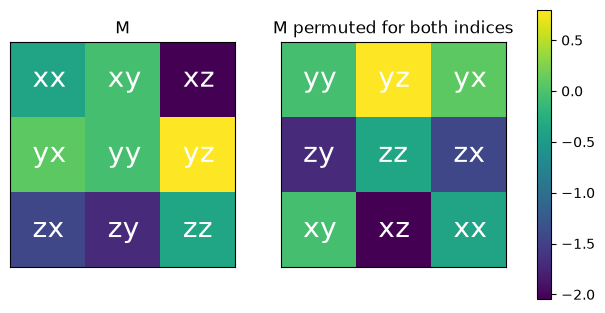

In [5]:
mx.random.seed(0)
# MLX equivalent of torch.randn(3, 3)
M = mx.random.normal(shape=(3, 3))
perm = mx.array([1, 2, 0])
# Permute indices to ('y', 'z', 'x') to be compatible with spherical harmonic convention
# Permute both axes from (x, y, z) to (y, z, x)


perm_M = mx.take(M, perm, axis=0)
perm_M = mx.take(perm_M, perm, axis=1)

import matplotlib.pyplot as plt
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(8, 5));
axes[0].matshow(M)
axes[0].set_title('M');
axes[0].get_xaxis().set_visible(False)
axes[0].get_yaxis().set_visible(False)
for i, x in enumerate(["x", "y", "z"]):
    for j, y in enumerate(["x", "y", "z"]):
        axes[0].text(j - 0.2, i + 0.1, x + y, {'color':'white', 'fontsize': 20})
    
im = axes[1].matshow(perm_M)
axes[1].set_title('M permuted for both indices');
axes[1].get_xaxis().set_visible(False)
axes[1].get_yaxis().set_visible(False)
for i, x in enumerate(["y", "z", "x"]):
    for j, y in enumerate(["y", "z", "x"]):
        axes[1].text(j - 0.2, i + 0.1, x + y, {'color':'white', 'fontsize': 20})
        
fig.colorbar(im, ax=axes[:], shrink=0.75);

## Rotating Cartesian and Spherical tensors
Our Cartesian matrix can be rotated with a 3D rotation matrix R applied to each Cartesian index.

$R_{ki} R_{lj} M_{ij} = M_{kl}$

As shown above, we can permute our Cartesian indices $(x, y, z)$ into those of L=1 spherical harmonics $(y, z, x)$.

We can even simplify the matrix by combining its two indices into a single index using the [Clebsch-Gordon coefficients](https://en.wikipedia.org/wiki/Clebsch%E2%80%93Gordan_coefficients).

$I_k = C_{ijk} M_{ij}$

where $C_{ijk}$ are the Clebsch-Gordon tensor. See Griffiths -- Introduction to Quantum Mechanics, Ch. 4 for more details.

We can then rotate this index using [Wigner D-matrices](https://en.wikipedia.org/wiki/Wigner_D-matrix), rotation matrices for the irreducible basis.

$I_{i} = D_{ij} I_j$

We can then convert back to the 3x3 matrix format to see that these rotations are indeed equivalent.

In [6]:
angles = mx.random.normal(shape=(3,)) * mx.array([np.pi, 2 * np.pi, np.pi])
rot = o3.angles_to_matrix(*angles)

# Rotate the Cartesian matrix directly: M' = R M R^T
rotated_M = mx.einsum("ki,ij,lj->kl", rot, M, rot)

# Decompose a rank-two Cartesian tensor into irreducible representations
cartesian = CartesianTensor(M)  # use the modern basis here
Rs_3x3, C = cartesian.to_irrep_transformation()
irreps = cartesian.irreps

# Historical SO(3)-only representation notation
Rs_3x3_legacy = [
    (part.mul, part.ir.l, 0)
    for part in irreps
]

print("Single index representation of 3x3 matrix:", Rs_3x3_legacy)
print("Shape of Clebsch-Gordon tensor:", C.shape)

# Direct sum of Wigner-D matrices for all irreps
wignerD = o3.irreps_wigner_d(irreps, *angles)
print("Shape of Wigner-D matrix:", wignerD.shape)

# Convert the Cartesian matrix to irrep coefficients
I = mx.einsum("kij,ij->k", C, M)

# Rotate those coefficients
rotated_I = wignerD @ I

# Convert the rotated coefficients back to Cartesian form
rotated_M_prime = mx.einsum("kij,k->ij", C, rotated_I)

print("Maximum error:", float(mx.max(mx.abs(rotated_M - rotated_M_prime))))

assert mx.allclose(
    rotated_M,
    rotated_M_prime,
    atol=1e-5,
    rtol=1e-5,
)

Single index representation of 3x3 matrix: [(1, 0, 0), (1, 1, 0), (1, 2, 0)]
Shape of Clebsch-Gordon tensor: (9, 3, 3)
Shape of Wigner-D matrix: (9, 9)
Maximum error: 3.1441450119018555e-06


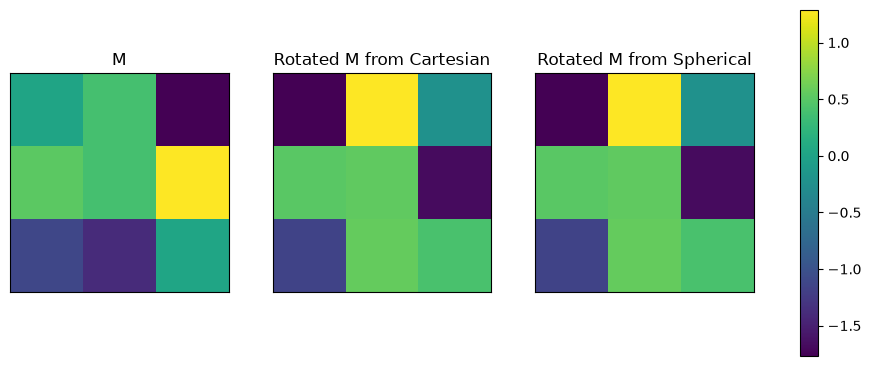

In [7]:
# Visualize M and rotated_M
import matplotlib.pyplot as plt
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(12, 6));
axes[0].matshow(M)
axes[0].set_title('M');
axes[0].get_xaxis().set_visible(False)
axes[0].get_yaxis().set_visible(False)
    
axes[1].matshow(rotated_M)
axes[1].set_title('Rotated M from Cartesian');
axes[1].get_xaxis().set_visible(False)
axes[1].get_yaxis().set_visible(False)

im = axes[2].matshow(rotated_M_prime)
axes[2].set_title("Rotated M from Spherical");
axes[2].get_xaxis().set_visible(False)
axes[2].get_yaxis().set_visible(False)
        
fig.colorbar(im, ax=axes[:], shrink=0.75);

## We can interpret our `SphericalTensors` as components of traditional geometric tensor or as geometry itself.

In [8]:
rows, cols = 1, 1
specs = [[{'is_3d': True} for i in range(cols)]
         for j in range(rows)]
fig = make_subplots(rows=rows, cols=cols, specs=specs)

L_max = 6
Rs = [(1, L) for L in range(L_max + 1)]
sum_Ls = sum(2 * L + 1 for mult, L in Rs) 

# Random spherical tensor up to L_Max
rand_sph_tensor = mx.random.normal(shape=(sum_Ls,))

sphten = SphericalTensor(rand_sph_tensor,) 
r, f = sphten.plot(relu=False, legacy_axes=True)                   
r, f = np.asarray(r), np.asarray(f)
trace = go.Surface(x=r[..., 0], y=r[..., 1], z=r[..., 2], surfacecolor=f)
fig.add_trace(trace, row=1, col=1)
fig.show()

In [ ]:
# Projection of tetrahedron on origin

rows, cols = 1, 1
specs = [[{'is_3d': True} for i in range(cols)]
         for j in range(rows)]
fig = make_subplots(rows=rows, cols=cols, specs=specs)

L_max = 6
tetra_coords = mx.array( # The easiest way to construct a tetrahedron is using opposite corners of a box
    [[0., 0., 0.], [1., 1., 0.], [1., 0., 1.], [0., 1., 1.]]
)
tetra_coords -= tetra_coords.mean(-2)

fig = make_subplots(rows=rows, cols=cols, specs=specs)

sphten = SphericalTensor.from_geometry(tetra_coords, L_max)
r, f = sphten.plot(relu=False, legacy_axes=True)
r, f = np.asarray(r), np.asarray(f)
trace = go.Surface(x=r[..., 0], y=r[..., 1], z=r[..., 2], surfacecolor=f)
fig.add_trace(trace, row=1, col=1)
fig.show()

## Common `CartesianTensors` as `IrrepTensors`

In [9]:
surface_plot = lambda r, f: go.Surface(x=r[..., 0], y=r[..., 1], z=r[..., 2], surfacecolor=f, showscale=False)

### Scalars $\rightarrow$ `Rs=[(1, 0, 1)]`

In [10]:
r, f = SphericalTensor(mx.ones(1)).plot()
trace_scalar = surface_plot(np.asarray(r), np.asarray(f))

### Vectors $\rightarrow$ `Rs=[(1, 1, -1)]`

In [11]:
vec = CartesianTensor(mx.random.normal(shape=(3,))).to_irrep_tensor()
print(vec.Rs)
r, f = SphericalTensor.from_irrep_tensor(vec).plot()
trace_vec = surface_plot(np.asarray(r), np.asarray(f))

[(1, 1, -1)]


### 3x3 Matrices $\rightarrow$ `Rs=[(1, 0, 1), (1, 1, 1), (1, 2, 1)]`

In [12]:
matrix = CartesianTensor(mx.random.normal(shape=(3,3))).to_irrep_tensor()
print(matrix.Rs)
r, f = SphericalTensor.from_irrep_tensor(matrix).plot()
trace_matrix = surface_plot(np.asarray(r), np.asarray(f))

[(1, 0, 1), (1, 1, 1), (1, 2, 1)]


### Symmetric 3x3 Matrices $\rightarrow$ `Rs=[(1, 0, 1), (1, 2, 1)]`

In [13]:
M = mx.random.normal(shape=(3,3))
matrix = CartesianTensor(M + M.transpose(1, 0), formula='ij=ji').to_irrep_tensor()
print(matrix.Rs)
r, f = SphericalTensor.from_irrep_tensor(matrix).plot()
trace_symm_matrix = surface_plot(np.asarray(r), np.asarray(f))

[(1, 0, 1), (1, 2, 1)]


### Rank-3 Tensor $\rightarrow$ `Rs=[(1, 0, -1), (3, 1, -1), (2, 2, -1), (1, 3, -1)]`

In [14]:
rank3 = CartesianTensor(mx.random.normal(shape=(3,3,3))).to_irrep_tensor()
print(rank3.Rs)
# Can't trivially visualize because we have multiple copies of irreps with same L
try:
    SphericalTensor.from_irrep_tensor(rank3)
except:
    pass
else:
    raise ValueError("That shouldn't have worked!")

[(1, 0, -1), (3, 1, -1), (2, 2, -1), (1, 3, -1)]


### Symmetric Rank-3 Tensor $\rightarrow$ `Rs=[(1, 1, -1), (1, 3, -1)]`

In [15]:
rank3 = mx.random.normal(shape=(3,3,3))
rank3_symm = (
    rank3
    + rank3.transpose(1, 0, 2)   # jik
    + rank3.transpose(0, 2, 1)   # ikj
)


rank3 = CartesianTensor(
    rank3_symm,
    formula='ijk=jik=ikj'
).to_irrep_tensor()

print(rank3.Rs)

r, f = SphericalTensor.from_irrep_tensor(rank3).plot()
trace_symm_rank3 = surface_plot(np.asarray(r), np.asarray(f))

[(1, 1, -1), (1, 3, -1)]


### Symmetric Rank-4 Tensor (e.g. Elasticity) $\rightarrow$ `Rs = [(2, 0, 1), (1, 1, 1), (3, 2, 1), (1, 3, 1), (1, 4, 1)]`

In [16]:
rank4 = mx.random.normal(shape=(3,3,3,3))
rank4_symm = (
    rank4
    + rank4.transpose(1, 0, 2, 3)   # jikl
    + rank4.transpose(0, 2, 1, 3)   # ijlk
)
rank4 = CartesianTensor(rank4_symm, formula='ijkl=jikl=ijlk').to_irrep_tensor()
print(rank4.Rs)
# Can't trivially visualize because we have multiple copies of irreps with same L
try:
    SphericalTensor.from_irrep_tensor(rank4)
except:
    pass
else:
    raise ValueError("That shouldn't have worked!")

[(2, 0, 1), (1, 1, 1), (3, 2, 1), (1, 3, 1), (1, 4, 1)]


In [17]:
rows, cols = 2, 3
specs = [[{'is_3d': True} for i in range(cols)]
         for j in range(rows)]
fig = make_subplots(rows=rows, cols=cols, specs=specs)

fig.add_trace(trace_scalar, row=1, col=1)
fig.add_trace(trace_vec, row=1, col=2)
fig.add_trace(trace_matrix, row=1, col=3)
fig.add_trace(trace_symm_matrix, row=2, col=1)
fig.add_trace(trace_symm_rank3, row=2, col=2)
fig.show()